In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
%matplotlib inline

In [34]:
df = pd.read_csv('cardekho_imputated.csv')

In [35]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [36]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [37]:
df[df['selling_price'] == df['selling_price'].max()]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3799,4845,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2,3800,Dealer,Petrol,Automatic,4.0,3855,601.0,4,39500000


In [38]:
df.brand.unique()

<ArrowStringArray>
[       'Maruti',       'Hyundai',          'Ford',       'Renault',
          'Mini', 'Mercedes-Benz',        'Toyota',    'Volkswagen',
         'Honda',      'Mahindra',        'Datsun',          'Tata',
           'Kia',           'BMW',          'Audi',    'Land Rover',
        'Jaguar',            'MG',         'Isuzu',       'Porsche',
         'Skoda',         'Volvo',         'Lexus',          'Jeep',
      'Maserati',       'Bentley',        'Nissan',         'ISUZU',
       'Ferrari',  'Mercedes-AMG',   'Rolls-Royce',         'Force']
Length: 32, dtype: str

In [39]:
df['fuel_type'].unique()

<ArrowStringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str

In [40]:
df['mileage'].unique()

array([19.7 , 18.9 , 17.  , 20.92, 22.77, 20.36, 20.51, 18.15, 16.6 ,
       22.32, 19.64, 14.41, 28.09, 25.2 , 19.27, 28.4 , 12.99, 21.4 ,
       20.85, 16.09, 19.67, 17.4 , 13.6 , 26.59, 17.7 , 17.19, 13.  ,
       23.01, 18.6 , 17.92, 15.1 , 23.4 , 22.54, 18.  , 21.  , 15.4 ,
       20.89, 26.6 , 22.5 , 17.8 , 20.54, 17.3 , 25.  , 24.  , 18.16,
       21.21, 14.  , 16.8 , 25.17, 24.3 , 18.5 , 23.84, 18.78, 11.74,
       25.1 , 21.01, 22.74, 21.9 , 15.6 , 19.1 , 22.07, 22.  , 23.1 ,
       23.  , 19.08, 18.27, 23.9 , 16.1 , 19.81, 19.44, 18.59, 20.62,
       17.01, 17.5 , 12.05, 25.83, 21.79, 13.7 , 16.47, 20.7 , 10.91,
       25.8 , 25.32, 19.87, 18.7 , 14.4 , 22.69, 20.73, 16.55, 20.  ,
       21.5 , 24.7 , 23.95, 21.63, 17.43, 25.47, 33.54, 15.96, 21.19,
       26.  , 12.55, 16.9 , 22.3 , 12.9 , 13.5 , 17.84, 27.28, 24.04,
       22.7 , 16.  , 17.6 , 21.7 , 20.45, 17.14, 19.6 , 20.4 , 12.63,
       17.1 , 15.37, 11.4 , 13.68, 17.68, 12.3 , 12.19, 17.33, 20.77,
       12.07, 20.3 ,

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.drop(columns=['Car ID','Model'],inplace=True)

KeyError: "['Car ID', 'Model'] not found in axis"

In [ ]:
df.columns

Index(['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage',
       'Condition', 'Price'],
      dtype='str')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le_brand = LabelEncoder()
le_fuel = LabelEncoder()
le_transmition = LabelEncoder()
le_condition = LabelEncoder()

In [ ]:
df['car age'] = 2026 - df['Year']

In [ ]:
df.drop(columns=['Year'],inplace=True)

In [ ]:
df.columns

Index(['Brand', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage',
       'Condition', 'Price', 'car age'],
      dtype='str')

In [ ]:
df['Brand'] = le_brand.fit_transform(df['Brand'])
df['Fuel Type'] = le_fuel.fit_transform(df['Fuel Type'])
df['Condition'] = le_condition.fit_transform(df['Condition'])
df['Transmission'] = le_transmition.fit_transform(df['Transmission'])

In [ ]:
df.head()

,Brand,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,car age
0,5,2.3,3,1,114832,1,26613.92,10
1,1,4.4,1,1,143190,2,14679.61,8
2,0,4.5,1,1,181601,1,44402.61,13
3,5,4.1,0,0,68682,1,86374.33,15
4,2,2.6,0,1,223009,0,73577.10,17


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         2500 non-null   int64  
 1   Engine Size   2500 non-null   float64
 2   Fuel Type     2500 non-null   int64  
 3   Transmission  2500 non-null   int64  
 4   Mileage       2500 non-null   int64  
 5   Condition     2500 non-null   int64  
 6   Price         2500 non-null   float64
 7   car age       2500 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 156.4 KB


In [ ]:
df.corr()

,Brand,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,car age
Brand,1.000000,0.006008,-0.013827,-0.013516,-0.013198,0.025755,0.001315,-0.017945
Engine Size,0.006008,1.000000,-0.011784,-0.004885,-0.015782,0.011435,-0.004420,-0.011833
Fuel Type,-0.013827,-0.011784,1.000000,-0.016989,0.014938,-0.026319,-0.034958,-0.012609
Transmission,-0.013516,-0.004885,-0.016989,1.000000,-0.024265,-0.008707,-0.001877,0.013961
Mileage,-0.013198,-0.015782,0.014938,-0.024265,1.000000,-0.015849,-0.008567,-0.002282
Condition,0.025755,0.011435,-0.026319,-0.008707,-0.015849,1.000000,-0.015669,-0.007243
Price,0.001315,-0.004420,-0.034958,-0.001877,-0.008567,-0.015669,1.000000,0.036805
car age,-0.017945,-0.011833,-0.012609,0.013961,-0.002282,-0.007243,0.036805,1.000000


<Axes: >

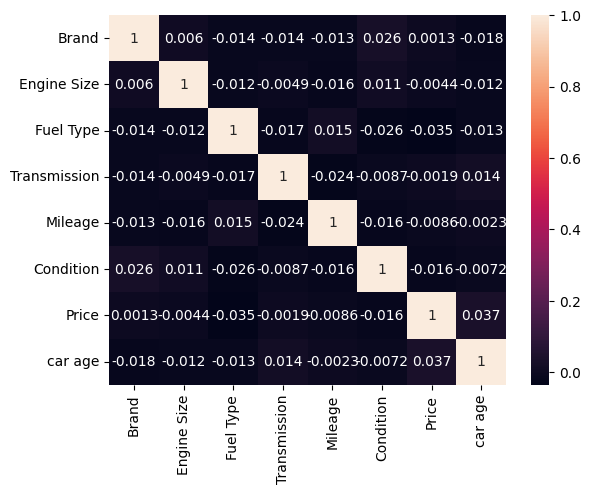

In [ ]:
sns.heatmap(df.corr(),annot=True)

In [ ]:
df.head()

,Brand,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,car age
0,5,2.3,3,1,114832,1,26613.92,10
1,1,4.4,1,1,143190,2,14679.61,8
2,0,4.5,1,1,181601,1,44402.61,13
3,5,4.1,0,0,68682,1,86374.33,15
4,2,2.6,0,1,223009,0,73577.10,17


In [ ]:
X = df.drop("Price",axis=1)
Y = df["Price"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=30,test_size=0.25)

In [ ]:
X_train.head()

,Brand,Engine Size,Fuel Type,Transmission,Mileage,Condition,car age
214,1,5.3,2,1,31357,1,17
540,6,5.6,0,1,31323,1,7
93,3,1.1,0,0,108730,0,16
1354,1,4.0,0,0,113922,2,20
1425,6,5.0,3,1,135669,2,21


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression,ElasticNet,Ridge
linear = LinearRegression()
elasticNet = Ridge()

In [ ]:
X_train_linear = linear.fit(X_train_scaler,Y_train)
Y_pred = linear.predict(X_test_scaler)

In [ ]:
X_train_elasticNet = elasticNet.fit(X_train_scaler,Y_train)
Y_pred_elasticNet = elasticNet.predict(X_test_scaler)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
mae = mean_absolute_error(Y_test, Y_pred_elasticNet)
mse = mean_squared_error(Y_test, Y_pred_elasticNet)
r2 = r2_score(Y_test, Y_pred_elasticNet)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 24403.950287913674
MSE: 783127990.3305233
R2: -0.02474352408318259


In [ ]:


mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 24404.091212164552
MSE: 783135638.980578
R2: -0.024753532542474366


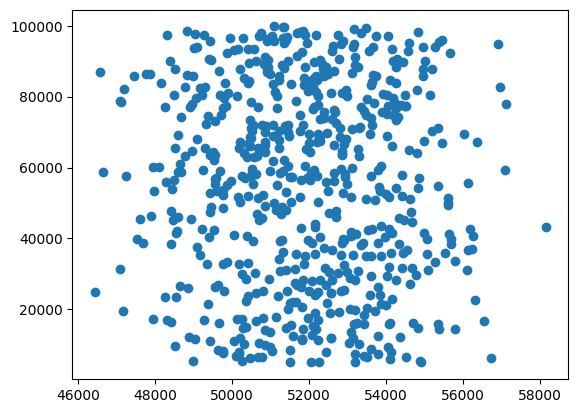

In [ ]:
plt.scatter(Y_pred,Y_test)

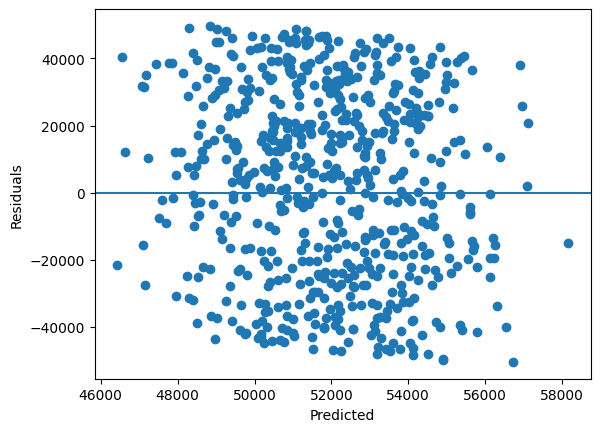

In [ ]:
residuals = Y_test - Y_pred

plt.scatter(Y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.show()

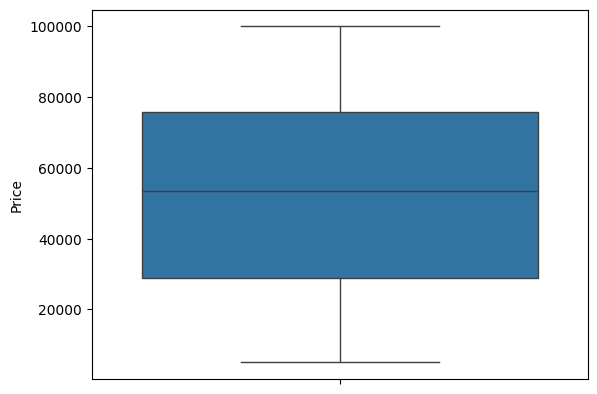

In [ ]:
sns.boxplot(df['Price'])
plt.show()

In [ ]:
X_train.columns

Index(['Brand', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage',
       'Condition', 'car age'],
      dtype='str')